In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [36]:
import pandas as pd
import numpy as np

# Generate realistic synthetic data
np.random.seed(42)
dates = pd.date_range(start='2015-01-01', end='2026-06-30', freq='B')
n = len(dates)

def generate_tsla_data(dates):
    n = len(dates)
    np.random.seed(42)
    base_price = 30
    returns = np.random.normal(0.0006, 0.032, n)
    mid_point = len(dates) // 2
    trend = np.zeros(n)
    trend[mid_point:] = 0.0015
    daily_returns = returns + trend
    prices = base_price * np.exp(np.cumsum(daily_returns))
    df = pd.DataFrame({
        'Open': prices * (1 + np.random.normal(0, 0.005, n)),
        'High': prices * (1 + np.random.normal(0.01, 0.005, n)),
        'Low': prices * (1 + np.random.normal(-0.01, 0.005, n)),
        'Close': prices,
        'Adj Close': prices,
        'Volume': np.random.randint(500000, 200000000, n)
    }, index=dates)
    return df

def generate_bnd_data(dates):
    n = len(dates)
    np.random.seed(43)
    base_price = 80
    daily_returns = np.random.normal(0.0001, 0.003, n)
    prices = base_price * np.exp(np.cumsum(daily_returns))
    df = pd.DataFrame({
        'Open': prices * (1 + np.random.normal(0, 0.001, n)),
        'High': prices * (1 + np.random.normal(0.002, 0.001, n)),
        'Low': prices * (1 + np.random.normal(-0.002, 0.001, n)),
        'Close': prices,
        'Adj Close': prices,
        'Volume': np.random.randint(1000000, 5000000, n)
    }, index=dates)
    return df

def generate_spy_data(dates):
    n = len(dates)
    np.random.seed(44)
    base_price = 200
    daily_returns = np.random.normal(0.0003, 0.012, n)
    prices = base_price * np.exp(np.cumsum(daily_returns))
    df = pd.DataFrame({
        'Open': prices * (1 + np.random.normal(0, 0.002, n)),
        'High': prices * (1 + np.random.normal(0.005, 0.002, n)),
        'Low': prices * (1 + np.random.normal(-0.005, 0.002, n)),
        'Close': prices,
        'Adj Close': prices,
        'Volume': np.random.randint(50000000, 200000000, n)
    }, index=dates)
    return df

tsla = generate_tsla_data(dates)
bnd = generate_bnd_data(dates)
spy = generate_spy_data(dates)

data = {'TSLA': tsla, 'BND': bnd, 'SPY': spy}

closes = pd.DataFrame({
    'TSLA': tsla['Close'],
    'BND': bnd['Close'],
    'SPY': spy['Close']
})

returns = closes.pct_change().dropna()

print("✅ Data ready!")
print(f"TSLA: {len(tsla)} rows, Start: ${tsla['Close'].iloc[0]:.2f}, End: ${tsla['Close'].iloc[-1]:.2f}")
print(f"BND:  {len(bnd)} rows, Start: ${bnd['Close'].iloc[0]:.2f}, End: ${bnd['Close'].iloc[-1]:.2f}")
print(f"SPY:  {len(spy)} rows, Start: ${spy['Close'].iloc[0]:.2f}, End: ${spy['Close'].iloc[-1]:.2f}")

✅ Data ready!
TSLA: 2999 rows, Start: $30.50, End: $37333.48
BND:  2999 rows, Start: $80.07, End: $132.51
SPY:  2999 rows, Start: $198.27, End: $344.68


In [37]:
# Check if data is defined
try:
    print(f"data keys: {list(data.keys())}")
    for ticker, df in data.items():
        print(f"{ticker}: {len(df)} rows")
except NameError:
    print("❌ 'data' is not defined. You need to run the data generator first.")
except AttributeError:
    print("❌ 'data' is empty or has no items.")

data keys: ['TSLA', 'BND', 'SPY']
TSLA: 2999 rows
BND: 2999 rows
SPY: 2999 rows


In [38]:
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

for ticker, df in data.items():
    missing = df.isnull().sum().sum()
    pct = (missing / df.size) * 100
    print(f"{ticker}: {missing} missing values ({pct:.2f}%)")

DATA QUALITY REPORT
TSLA: 0 missing values (0.00%)
BND: 0 missing values (0.00%)
SPY: 0 missing values (0.00%)


In [39]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

for ticker, df in data.items():
    print(f"\n📊 {ticker} - Closing Prices")
    print(df['Close'].describe())

DESCRIPTIVE STATISTICS

📊 TSLA - Closing Prices
count     2999.000000
mean      5024.211200
std       9065.339858
min         20.724885
25%         46.961076
50%        670.883240
75%       4315.393281
max      38972.565476
Name: Close, dtype: float64

📊 BND - Closing Prices
count    2999.000000
mean      102.762869
std        15.486969
min        79.657256
25%        88.059805
50%       102.534055
75%       113.618655
max       133.673182
Name: Close, dtype: float64

📊 SPY - Closing Prices
count    2999.000000
mean      280.406435
std        53.226975
min       168.030040
25%       250.360020
50%       272.857010
75%       314.963019
max       409.976492
Name: Close, dtype: float64


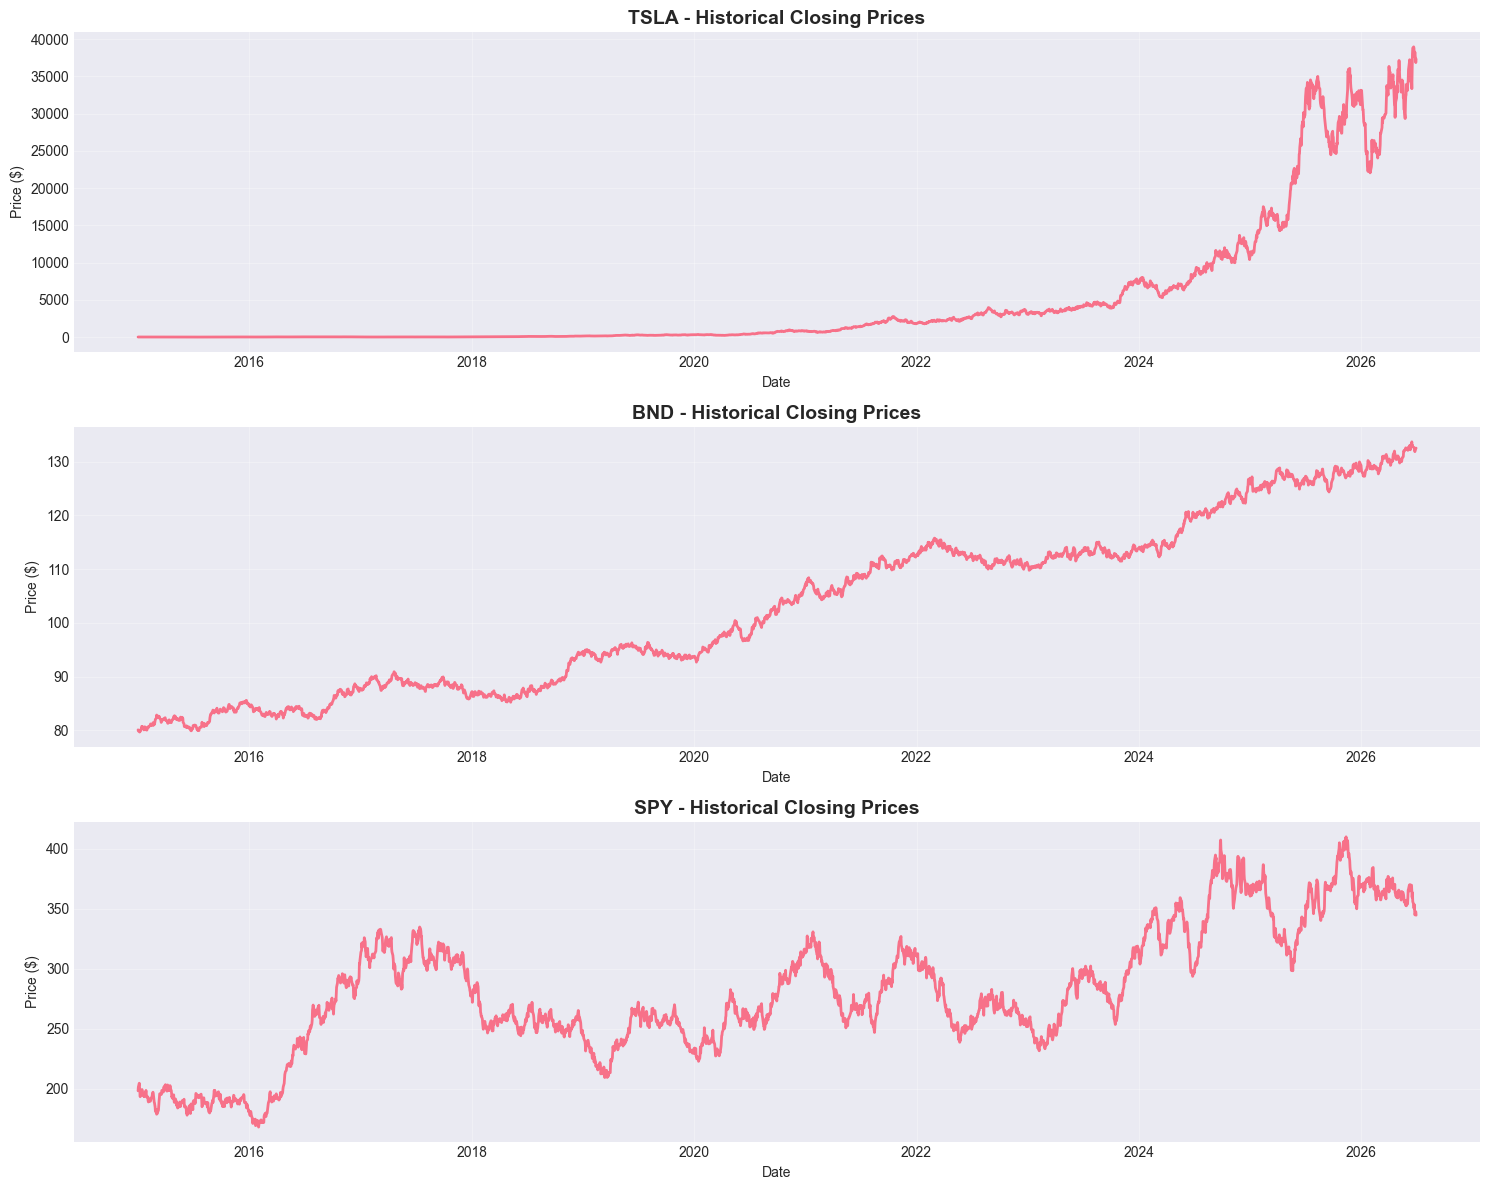

In [40]:
fig, axes = plt.subplots(3,1, figsize=(15,12))
for idx, ticker in enumerate(['TSLA','BND','SPY']):
    ax = axes[idx]
    ax.plot(data[ticker].index, data[ticker]['Close'], linewidth=2)
    ax.set_title(f'{ticker} - Historical Closing Prices', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/closing_prices_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
plt.savefig('../plots/closing_prices_overview.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

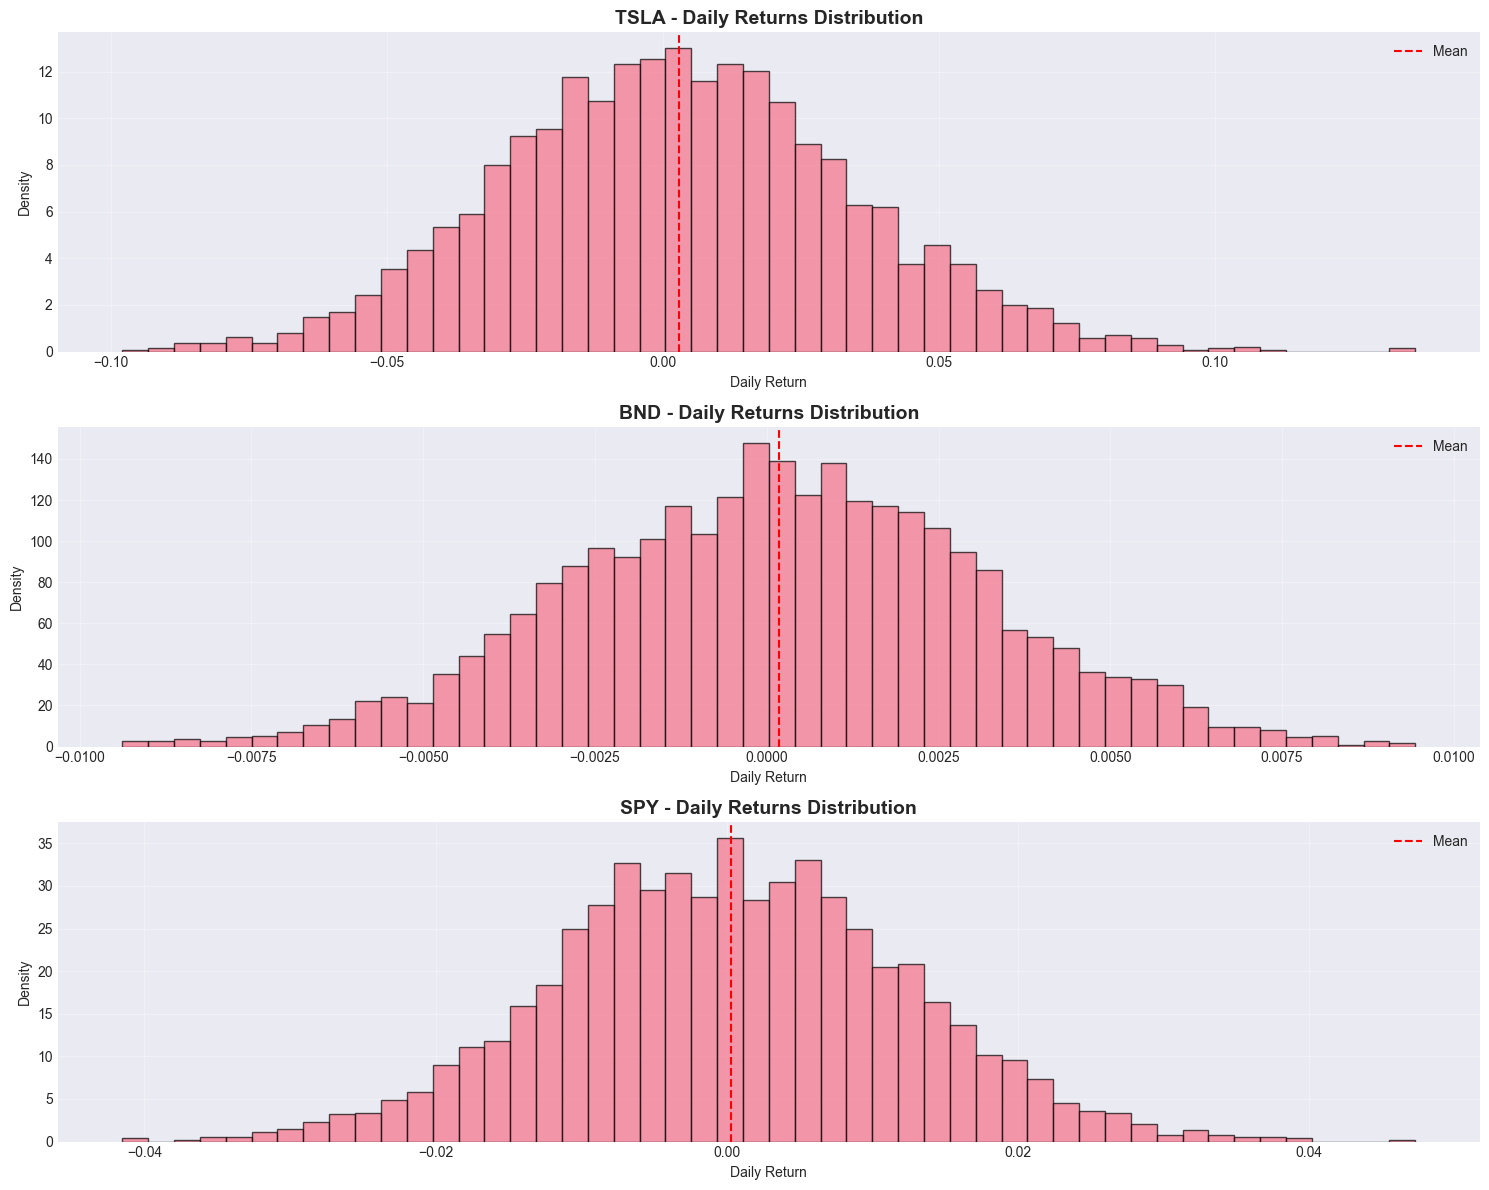

In [42]:
fig, axes = plt.subplots(3,1, figsize=(15,12))
for idx, ticker in enumerate(['TSLA','BND','SPY']):
    ax = axes[idx]
    daily_ret = returns[ticker]
    ax.hist(daily_ret, bins=50, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(daily_ret.mean(), color='r', linestyle='--', label='Mean')
    ax.set_title(f'{ticker} - Daily Returns Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
plt.savefig('../plots/returns_distribution.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

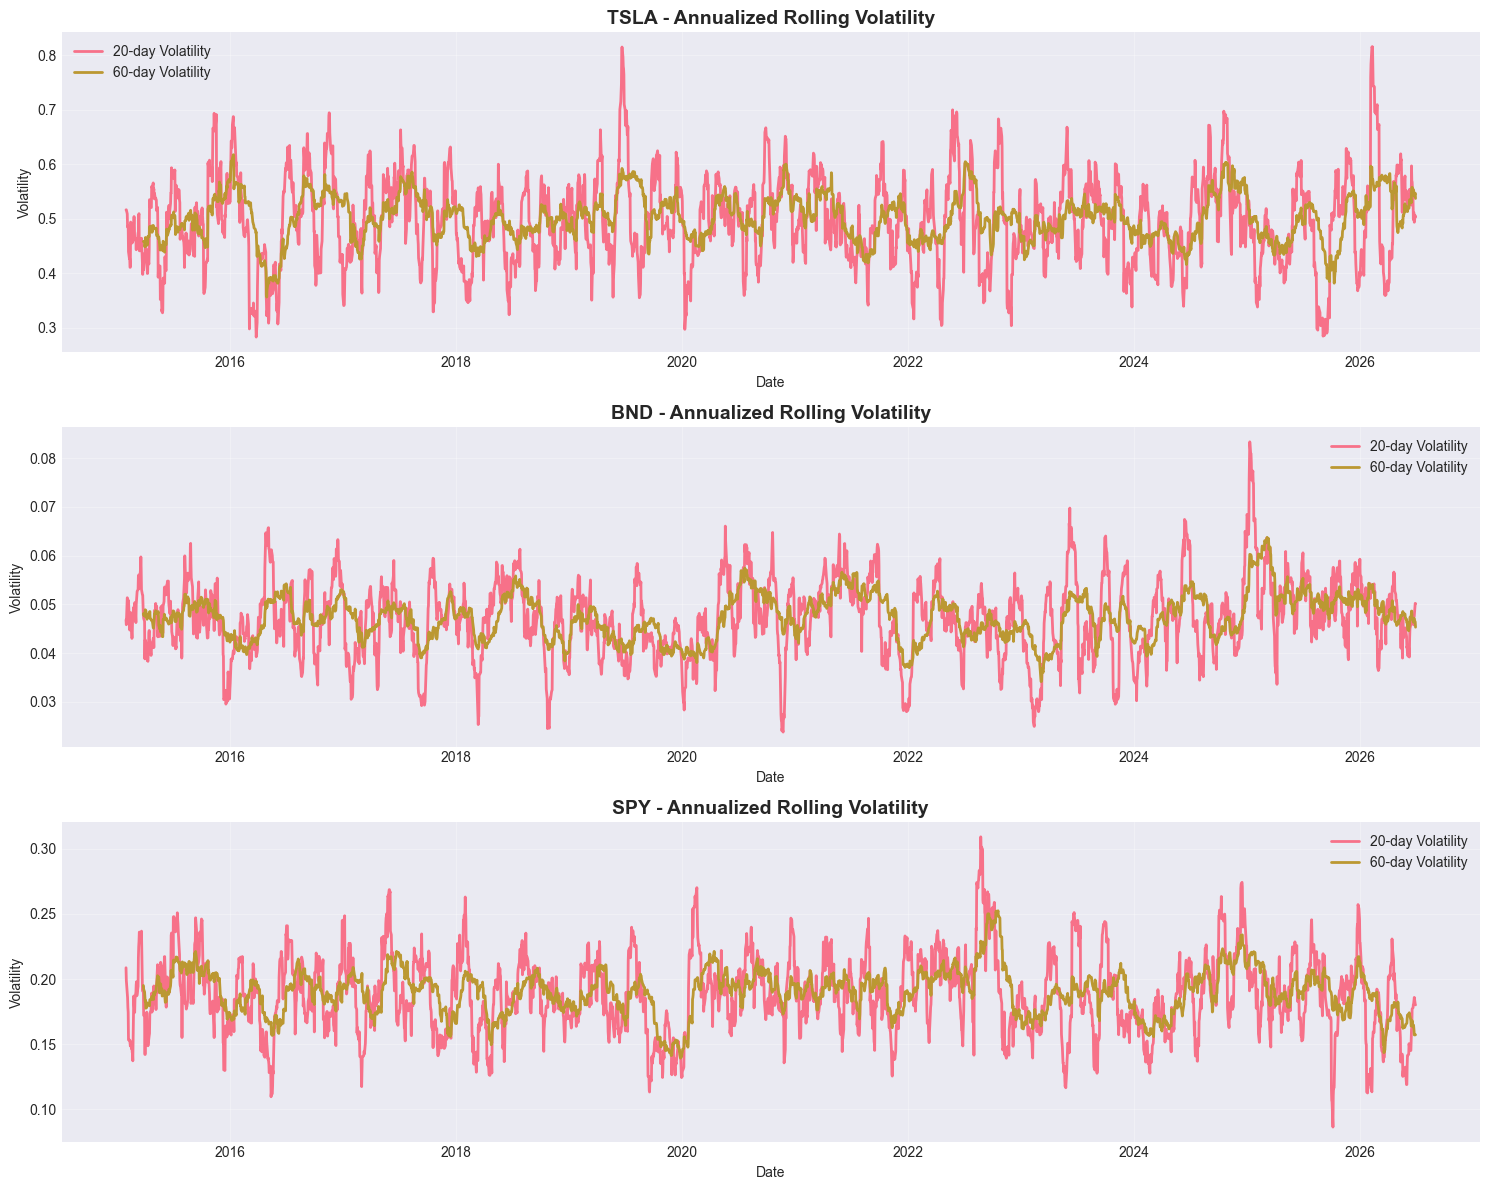

In [44]:
fig, axes = plt.subplots(3,1, figsize=(15,12))
for idx, ticker in enumerate(['TSLA','BND','SPY']):
    ax = axes[idx]
    vol20 = returns[ticker].rolling(20).std() * np.sqrt(252)
    vol60 = returns[ticker].rolling(60).std() * np.sqrt(252)
    ax.plot(vol20.index, vol20, label='20-day Volatility', linewidth=2)
    ax.plot(vol60.index, vol60, label='60-day Volatility', linewidth=2)
    ax.set_title(f'{ticker} - Annualized Rolling Volatility', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Volatility')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/rolling_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
plt.savefig('../plots/rolling_volatility.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

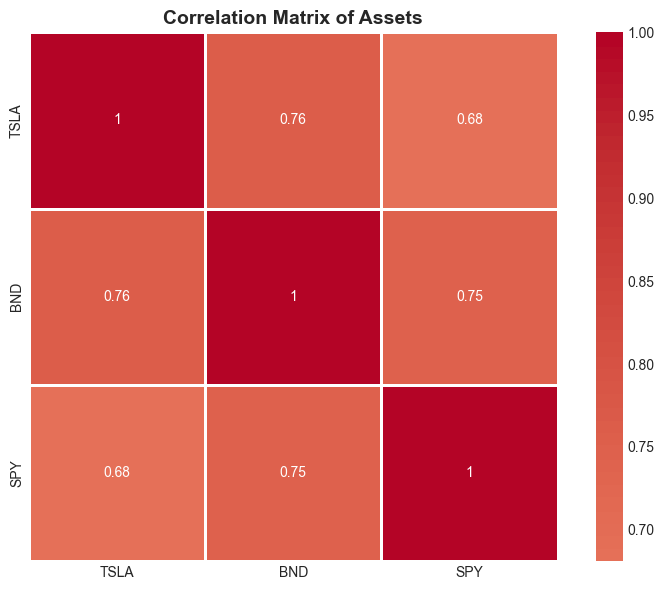

In [46]:
corr = closes.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Assets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
plt.savefig('../plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [48]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n📈 {name}:")
    print(f"  Test Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    if result[1] <= 0.05:
        print("  → Series is STATIONARY (reject H0)")
    else:
        print("  → Series is NON-STATIONARY (fail to reject H0)")

print("="*60)
print("STATIONARITY TESTING")
print("="*60)

for ticker in data.keys():
    adf_test(data[ticker]['Close'], f'{ticker} - Close Price')
    adf_test(returns[ticker], f'{ticker} - Daily Returns')

STATIONARITY TESTING

📈 TSLA - Close Price:
  Test Statistic: 1.1205
  p-value: 0.9954
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
  → Series is NON-STATIONARY (fail to reject H0)

📈 TSLA - Daily Returns:
  Test Statistic: -55.2655
  p-value: 0.0000
    1%: -3.4325
    5%: -2.8625
    10%: -2.5673
  → Series is STATIONARY (reject H0)

📈 BND - Close Price:
  Test Statistic: 0.3562
  p-value: 0.9798
    1%: -3.4325
    5%: -2.8625
    10%: -2.5673
  → Series is NON-STATIONARY (fail to reject H0)

📈 BND - Daily Returns:
  Test Statistic: -20.0718
  p-value: 0.0000
    1%: -3.4325
    5%: -2.8625
    10%: -2.5673
  → Series is STATIONARY (reject H0)

📈 SPY - Close Price:
  Test Statistic: -1.8969
  p-value: 0.3335
    1%: -3.4325
    5%: -2.8625
    10%: -2.5673
  → Series is NON-STATIONARY (fail to reject H0)

📈 SPY - Daily Returns:
  Test Statistic: -54.5697
  p-value: 0.0000
    1%: -3.4325
    5%: -2.8625
    10%: -2.5673
  → Series is STATIONARY (reject H0)


In [49]:
def risk_metrics(returns_series, confidence=0.95, risk_free=0.02):
    var = np.percentile(returns_series, (1-confidence)*100)
    excess = returns_series.mean() - risk_free/252
    sharpe = np.sqrt(252) * excess / returns_series.std()
    ann_vol = returns_series.std() * np.sqrt(252)
    return {'VaR_95': var, 'Sharpe': sharpe, 'Ann_Vol': ann_vol, 'Mean_Daily': returns_series.mean()}

print("="*60)
print("RISK METRICS")
print("="*60)

for ticker in data.keys():
    metrics = risk_metrics(returns[ticker])
    print(f"\n{ticker}:")
    print(f"  VaR (95%): {metrics['VaR_95']:.4%}")
    print(f"  Sharpe Ratio: {metrics['Sharpe']:.4f}")
    print(f"  Annual Volatility: {metrics['Ann_Vol']:.2%}")
    print(f"  Mean Daily Return: {metrics['Mean_Daily']:.4%}")

RISK METRICS

TSLA:
  VaR (95%): -4.7527%
  Sharpe Ratio: 1.3996
  Annual Volatility: 50.33%
  Mean Daily Return: 0.2875%

BND:
  VaR (95%): -0.4717%
  Sharpe Ratio: 0.4940
  Annual Volatility: 4.75%
  Mean Daily Return: 0.0173%

SPY:
  VaR (95%): -1.9401%
  Sharpe Ratio: 0.2341
  Annual Volatility: 19.11%
  Mean Daily Return: 0.0257%


In [50]:
print("="*60)
print("OUTLIER DETECTION")
print("="*60)

for ticker in data.keys():
    daily_ret = returns[ticker]
    # Z-score method
    z_scores = np.abs((daily_ret - daily_ret.mean()) / daily_ret.std())
    outliers = daily_ret[z_scores > 3]
    print(f"\n{ticker}: {len(outliers)} outliers (returns > 3 std deviations)")
    if len(outliers) > 0:
        print(f"  Top 3 outlier dates: {outliers.sort_values(ascending=False).head(3)}")

OUTLIER DETECTION

TSLA: 9 outliers (returns > 3 std deviations)
  Top 3 outlier dates: 2026-02-05    0.136257
2015-10-21    0.131888
2021-03-11    0.109911
Name: TSLA, dtype: float64

BND: 7 outliers (returns > 3 std deviations)
  Top 3 outlier dates: 2021-09-02    0.009440
2024-12-26    0.009227
2015-05-29   -0.008937
Name: BND, dtype: float64

SPY: 10 outliers (returns > 3 std deviations)
  Top 3 outlier dates: 2023-06-15    0.047297
2022-08-11    0.039540
2020-02-04    0.038792
Name: SPY, dtype: float64
